# 02 — Baseline Sales Forecasting

**Mục tiêu:** Dự báo `Revenue` và `COGS` hàng ngày cho giai đoạn `2023-01-01 → 2024-07-01`  
**Chiến lược:** Simple Seasonal Average + YoY Trend  

### Tổng quan Pipeline

```
sales.csv  ──►  Feature Engineering  ──►  Seasonal Profile  ──►  Trend Projection
                                                                        │
                                          Validation (MAPE) ◄──────────┤
                                                                        │
                                          submission.csv    ◄───────────┘
```

| Bước | Nội dung |
|------|----------|
| 1 | Imports & Config |
| 2 | Load & Inspect Data |
| 3 | Feature Engineering |
| 4 | Build Seasonal Profile |
| 5 | Predict Test Period |
| 6 | Evaluate — Validation MAPE |
| 7 | Export Submission |

---
## 1 — Imports & Config

Khai báo tất cả thư viện và đường dẫn tập trung tại một chỗ để dễ bảo trì.  
**Seed** được đặt để đảm bảo tính tái lập (reproducibility) theo yêu cầu đề bài.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility seed (không ảnh hưởng baseline nhưng đặt để nhất quán) ──
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Đường dẫn dữ liệu ────────────────────────────────────────────────────────
DATA_DIR   = '/kaggle/input/competitions/datathon-2026-round-1/'          # thư mục chứa toàn bộ CSV
TRAIN_FILE = DATA_DIR + 'sales.csv'          # lịch sử 2012-07-04 → 2022-12-31
TEST_FILE  = DATA_DIR + 'sample_submission.csv'     # khoảng cần dự báo  2023-01-01 → 2024-07-01
SAMPLE_SUB = DATA_DIR + 'sample_submission.csv'  # file mẫu để kiểm tra thứ tự cột
OUT_FILE   = 'submission.csv'    # file nộp bài Kaggle

# ── Matplotlib style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('✅ Imports & config OK')

✅ Imports & config OK


---
## 2 — Load & Inspect Data

Đọc tập train và test, kiểm tra:
- Khoảng thời gian (date range)
- Giá trị thiếu (missing values)
- Phân phối tổng quát

In [2]:
# ── Đọc dữ liệu ──────────────────────────────────────────────────────────────
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['Date'])

# ── Báo cáo nhanh ────────────────────────────────────────────────────────────
print('=' * 55)
print(f"{'TRAIN':}".center(55))
print('=' * 55)
print(f"  Shape       : {train.shape}")
print(f"  Date range  : {train['Date'].min().date()}  →  {train['Date'].max().date()}")
print(f"  Missing vals: {train.isnull().sum().to_dict()}")
print()
print('=' * 55)
print(f"{'TEST':}".center(55))
print('=' * 55)
print(f"  Shape       : {test.shape}")
print(f"  Date range  : {test['Date'].min().date()}  →  {test['Date'].max().date()}")
print(f"  Missing vals: {test.isnull().sum().to_dict()}")
print()
train.describe().round(2)

                         TRAIN                         
  Shape       : (3833, 3)
  Date range  : 2012-07-04  →  2022-12-31
  Missing vals: {'Date': 0, 'Revenue': 0, 'COGS': 0}

                          TEST                         
  Shape       : (548, 3)
  Date range  : 2023-01-01  →  2024-07-01
  Missing vals: {'Date': 0, 'Revenue': 0, 'COGS': 0}



,Date,Revenue,COGS
count,3833,3833.00,3833.00
mean,2017-10-02 00:00:00,4286584.03,3695134.49
min,2012-07-04 00:00:00,279813.94,236576.31
25%,2015-02-17 00:00:00,2471088.82,2150580.23
50%,2017-10-02 00:00:00,3647303.90,3161112.99
75%,2020-05-17 00:00:00,5350877.20,4637293.92
max,2022-12-31 00:00:00,20905271.35,16535857.67
std,NaN,2624840.20,2219788.77


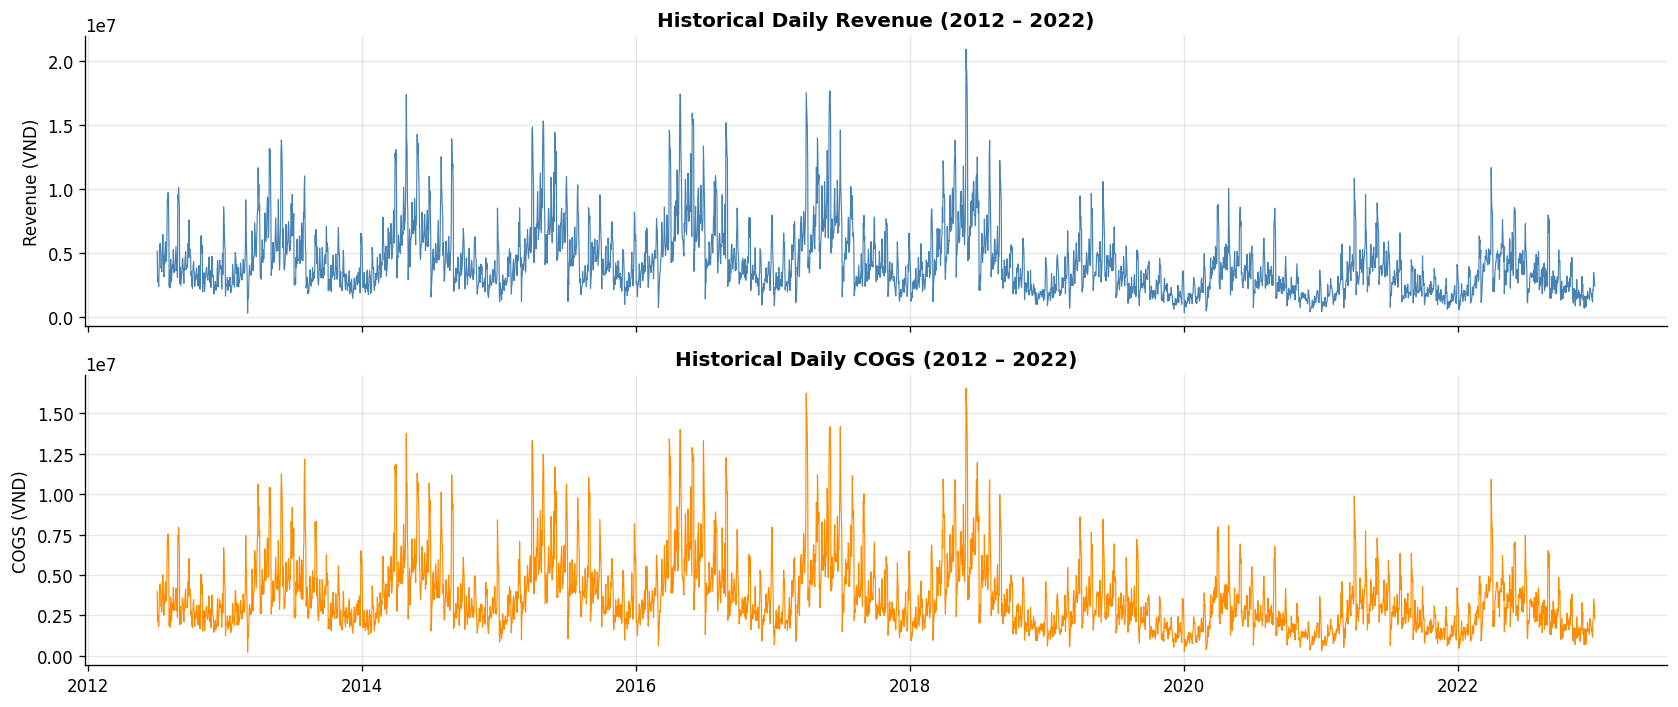

📊 Chart saved: plot_01_historical.png


In [3]:
# ── Visualise lịch sử toàn bộ ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(train['Date'], train['Revenue'], lw=0.7, color='steelblue')
axes[0].set_title('Historical Daily Revenue (2012 – 2022)', fontweight='bold')
axes[0].set_ylabel('Revenue (VND)')

axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='darkorange')
axes[1].set_title('Historical Daily COGS (2012 – 2022)', fontweight='bold')
axes[1].set_ylabel('COGS (VND)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('plot_01_historical.png', bbox_inches='tight')
plt.show()
print('📊 Chart saved: plot_01_historical.png')

---
## 3 — Feature Engineering

Tách các thành phần thời gian cần thiết và tính **annual totals** để ước tính tốc độ tăng trưởng YoY.

> **Lưu ý:** Chỉ dùng các năm có dữ liệu **đầy đủ 365 ngày** (2013–2022) để tính growth rate. Năm 2012 bắt đầu từ 04/07 nên bị loại.

In [4]:
# ── Thêm các cột thời gian vào tập train ─────────────────────────────────────
train['year']        = train['Date'].dt.year
train['month']       = train['Date'].dt.month
train['day']         = train['Date'].dt.day
train['day_of_year'] = train['Date'].dt.dayofyear

# ── Tổng doanh thu theo năm ───────────────────────────────────────────────────
annual = train.groupby('year')[['Revenue', 'COGS']].sum()

print('Tổng doanh thu theo năm:')
print(annual.to_string())

Tổng doanh thu theo năm:
           Revenue          COGS
year                            
2012  7.414977e+08  5.874619e+08
2013  1.657169e+09  1.465980e+09
2014  1.871846e+09  1.574607e+09
2015  1.889934e+09  1.665442e+09
2016  2.104641e+09  1.780559e+09
2017  1.911164e+09  1.694386e+09
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.054512e+09  8.860851e+08
2021  1.043040e+09  9.411301e+08
2022  1.169749e+09  1.020420e+09


In [5]:
# ── Tính YoY Growth Rate (Geometric Mean) ────────────────────────────────────
# Chỉ dùng các năm có dữ liệu đầy đủ: 2013 → 2022  (2012 bị cắt cụt)
FULL_YEARS_START = 2013
FULL_YEARS_END   = 2022

full_years = annual.loc[FULL_YEARS_START:FULL_YEARS_END]

# Tốc độ tăng trưởng từng năm (YoY)
yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

# Geometric mean: CAGR = (product of (1+r_i))^(1/n)
n_periods   = len(yoy_rev)          # = 9 khoảng (2013→2022)
growth_rev  = (1 + yoy_rev).prod()  ** (1 / n_periods)
growth_cogs = (1 + yoy_cogs).prod() ** (1 / n_periods)

print(f'Số khoảng YoY dùng để tính CAGR : {n_periods}')
print(f'CAGR Revenue : {growth_rev:.6f}  ({(growth_rev - 1) * 100:.3f}% / năm)')
print(f'CAGR COGS    : {growth_cogs:.6f}  ({(growth_cogs - 1) * 100:.3f}% / năm)')

Số khoảng YoY dùng để tính CAGR : 9
CAGR Revenue : 0.962037  (-3.796% / năm)
CAGR COGS    : 0.960543  (-3.946% / năm)


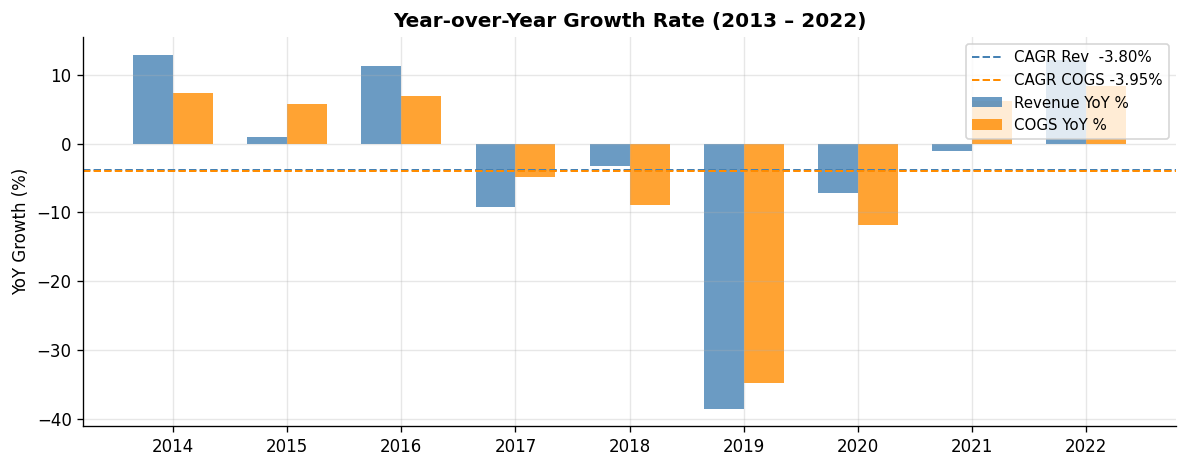

📊 Chart saved: plot_02_yoy_growth.png


In [6]:
# ── Trực quan hoá YoY growth ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

years = yoy_rev.index
width = 0.35
x     = np.arange(len(years))

ax.bar(x - width/2, yoy_rev.values  * 100, width, label='Revenue YoY %', color='steelblue', alpha=0.8)
ax.bar(x + width/2, yoy_cogs.values * 100, width, label='COGS YoY %',    color='darkorange', alpha=0.8)
ax.axhline((growth_rev  - 1) * 100, ls='--', lw=1.2, color='steelblue',   label=f'CAGR Rev  {(growth_rev -1)*100:.2f}%')
ax.axhline((growth_cogs - 1) * 100, ls='--', lw=1.2, color='darkorange',  label=f'CAGR COGS {(growth_cogs-1)*100:.2f}%')
ax.set_xticks(x); ax.set_xticklabels(years)
ax.set_title('Year-over-Year Growth Rate (2013 – 2022)', fontweight='bold')
ax.set_ylabel('YoY Growth (%)')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('plot_02_yoy_growth.png', bbox_inches='tight')
plt.show()
print('📊 Chart saved: plot_02_yoy_growth.png')

---
## 4 — Build Seasonal Profile

### Ý tưởng
Thay vì dùng giá trị tuyệt đối (sẽ bị méo bởi xu hướng tăng qua các năm), ta **chuẩn hóa** từng ngày bằng cách chia cho **trung bình năm** của nó. Sau đó lấy trung bình theo **(tháng, ngày)** qua toàn bộ lịch sử:

$$
\text{seasonal\_factor}_{(m,d)} = \frac{1}{|\mathcal{Y}|} \sum_{y \in \mathcal{Y}} \frac{x_{y,m,d}}{\bar{x}_y}
$$

Kết quả là một hệ số **scale-free** phản ánh thuần túy mẫu mùa vụ, tách biệt hoàn toàn khỏi mức nền (level) của từng năm.

In [7]:
# ── Bước 1: Chuẩn hóa từng ngày theo trung bình năm của nó ──────────────────
# transform('mean') broadcast mean của năm xuống từng dòng
annual_means = train.groupby('year')[['Revenue', 'COGS']].transform('mean')

# rev_norm = Revenue_ngày / Revenue_trung_bình_năm → giá trị xoay quanh 1.0
train['rev_norm']  = train['Revenue'] / annual_means['Revenue']
train['cogs_norm'] = train['COGS']    / annual_means['COGS']

print('Kiểm tra rev_norm — mean nên ≈ 1.0 cho từng năm:')
print(train.groupby('year')[['rev_norm', 'cogs_norm']].mean().round(6).to_string())

Kiểm tra rev_norm — mean nên ≈ 1.0 cho từng năm:
      rev_norm  cogs_norm
year                     
2012       1.0        1.0
2013       1.0        1.0
2014       1.0        1.0
2015       1.0        1.0
2016       1.0        1.0
2017       1.0        1.0
2018       1.0        1.0
2019       1.0        1.0
2020       1.0        1.0
2021       1.0        1.0
2022       1.0        1.0


In [8]:
# ── Bước 2: Tính seasonal profile theo (month, day) ──────────────────────────
seasonal = (
    train
    .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
    .mean()
    .reset_index()
)

print(f'Seasonal profile: {len(seasonal)} bản ghi (tối đa 366 tương ứng các ngày trong năm)')
print()
print('Mẫu 10 dòng đầu:')
print(seasonal.head(10).to_string(index=False))

Seasonal profile: 366 bản ghi (tối đa 366 tương ứng các ngày trong năm)

Mẫu 10 dòng đầu:
 month  day  rev_norm  cogs_norm
     1    1  0.864547   0.938006
     1    2  0.415165   0.423207
     1    3  0.329503   0.306372
     1    4  0.370727   0.340570
     1    5  0.400993   0.366576
     1    6  0.418113   0.387441
     1    7  0.444529   0.416864
     1    8  0.457043   0.425623
     1    9  0.481326   0.454805
     1   10  0.509432   0.468719


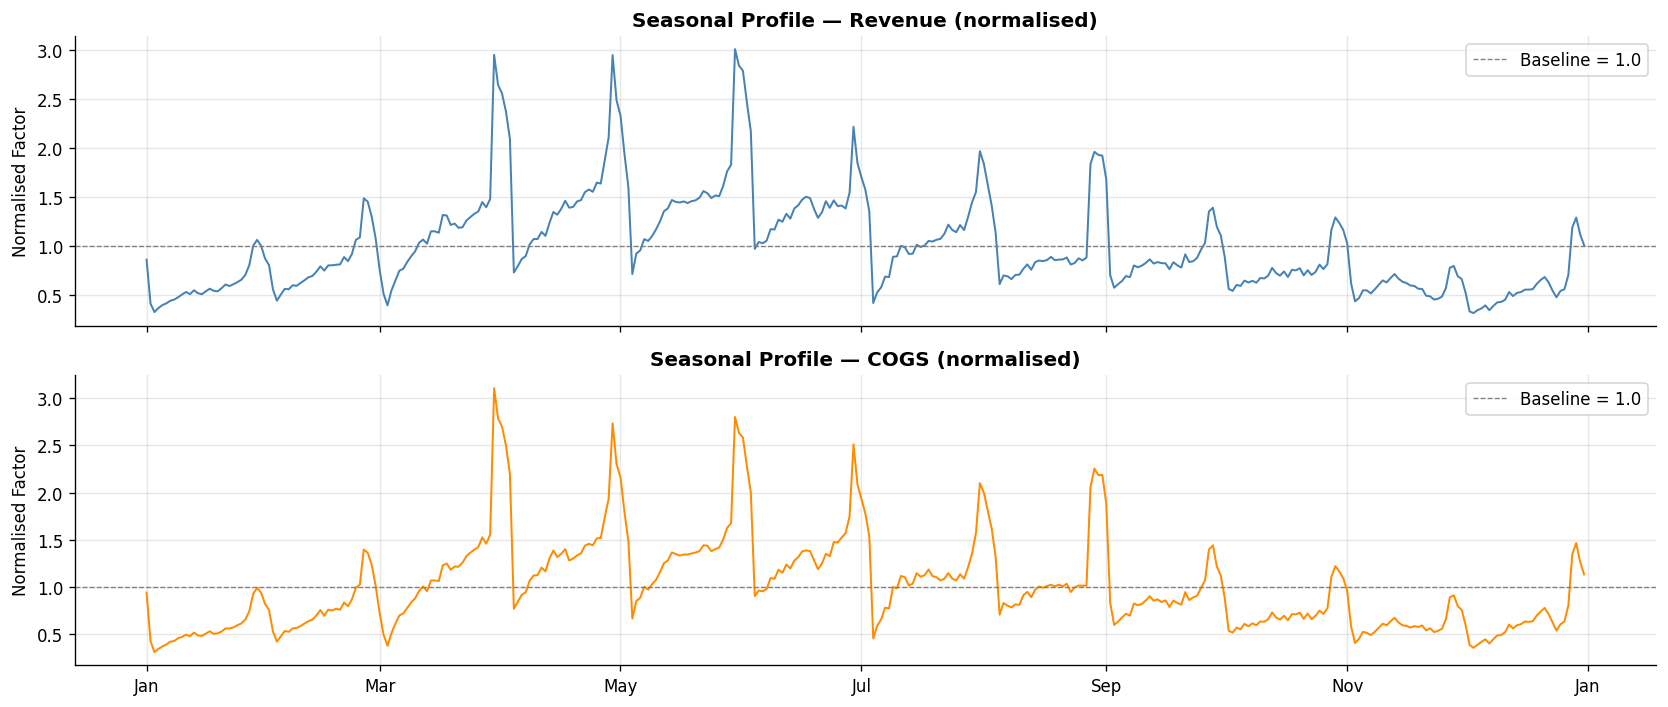

📊 Chart saved: plot_03_seasonal_profile.png


In [9]:
# ── Trực quan hoá seasonal profile theo tháng ────────────────────────────────
# Tạo chuỗi ngày giả (dùng năm 2019 — năm thường có đủ 365 ngày) để plot
dummy_dates = pd.date_range('2019-01-01', '2019-12-31', freq='D')
dummy_df    = pd.DataFrame({'Date': dummy_dates})
dummy_df['month'] = dummy_df['Date'].dt.month
dummy_df['day']   = dummy_df['Date'].dt.day
dummy_df = dummy_df.merge(seasonal, on=['month', 'day'], how='left')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(dummy_df['Date'], dummy_df['rev_norm'],  color='steelblue',  lw=1.2)
axes[0].axhline(1.0, ls='--', lw=0.8, color='gray', label='Baseline = 1.0')
axes[0].set_title('Seasonal Profile — Revenue (normalised)', fontweight='bold')
axes[0].set_ylabel('Normalised Factor')
axes[0].legend()

axes[1].plot(dummy_df['Date'], dummy_df['cogs_norm'], color='darkorange', lw=1.2)
axes[1].axhline(1.0, ls='--', lw=0.8, color='gray', label='Baseline = 1.0')
axes[1].set_title('Seasonal Profile — COGS (normalised)', fontweight='bold')
axes[1].set_ylabel('Normalised Factor')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_03_seasonal_profile.png', bbox_inches='tight')
plt.show()
print('📊 Chart saved: plot_03_seasonal_profile.png')

---
## 5 — Predict Test Period

### Công thức dự báo

$$
\hat{y}_{d} = \underbrace{\text{base\_level}}_{\text{mức nền 2022}} \times \underbrace{g^{\Delta t}}_{\text{trend}} \times \underbrace{s_{(m,d)}}_{\text{seasonal factor}}
$$

| Ký hiệu | Ý nghĩa |
|---------|----------|
| `base_level` | Doanh thu/COGS trung bình **ngày** của năm 2022 (năm hoàn chỉnh gần nhất) |
| `g` | CAGR (compound annual growth rate) tính ở Bước 3 |
| `Δt` | Số năm cách xa năm 2022 (có thể là số thực nếu cần, ở đây dùng `year - 2022`) |
| `s_(m,d)` | Seasonal factor của ngày `(month, day)` từ seasonal profile |

In [10]:
# ── Mức nền: trung bình NGÀY của năm 2022 ────────────────────────────────────
# Lấy tổng năm 2022 chia cho 365 ngày
base_rev  = annual.loc[2022, 'Revenue'] / 365
base_cogs = annual.loc[2022, 'COGS']    / 365

print(f'Base level 2022 — Revenue/ngày : {base_rev:,.2f}')
print(f'Base level 2022 — COGS/ngày    : {base_cogs:,.2f}')

Base level 2022 — Revenue/ngày : 3,204,791.32
Base level 2022 — COGS/ngày    : 2,795,671.68


In [11]:
# ── Chuẩn bị tập test ────────────────────────────────────────────────────────
test = test.copy()  # tránh SettingWithCopyWarning
test['month']       = test['Date'].dt.month
test['day']         = test['Date'].dt.day
test['year']        = test['Date'].dt.year

# Số năm chênh lệch so với năm gốc 2022
BASE_YEAR          = 2022
test['years_ahead'] = test['year'] - BASE_YEAR

# ── Gán seasonal factor ──────────────────────────────────────────────────────
test = test.merge(seasonal, on=['month', 'day'], how='left')

# Lấp NaN (chỉ xảy ra với 29/02 khi tập huấn luyện không có năm nhuận đủ dữ liệu)
# → dùng factor = 1.0 (không có thông tin mùa vụ đặc biệt)
missing_days = test[test['rev_norm'].isna()][['Date']]
if len(missing_days):
    print(f'⚠️  {len(missing_days)} ngày thiếu seasonal factor (fillna=1.0): {missing_days["Date"].tolist()}')
else:
    print('✅ Không có ngày nào thiếu seasonal factor.')

test['rev_norm']  = test['rev_norm'].fillna(1.0)
test['cogs_norm'] = test['cogs_norm'].fillna(1.0)

# ── Áp dụng công thức dự báo ─────────────────────────────────────────────────
# Revenue_pred = base_rev  × growth_rev^years_ahead  × seasonal_factor_rev
# COGS_pred    = base_cogs × growth_cogs^years_ahead × seasonal_factor_cogs
test['Revenue'] = (base_rev  * growth_rev**test['years_ahead']  * test['rev_norm'] ).round(2)
test['COGS']    = (base_cogs * growth_cogs**test['years_ahead'] * test['cogs_norm']).round(2)

# Đảm bảo không có giá trị âm (bảo vệ hợp lý)
test['Revenue'] = test['Revenue'].clip(lower=0)
test['COGS']    = test['COGS'].clip(lower=0)

print()
print('Mẫu 10 dòng dự báo:')
print(test[['Date', 'Revenue', 'COGS']].head(10).to_string(index=False))

✅ Không có ngày nào thiếu seasonal factor.

Mẫu 10 dòng dự báo:
      Date    Revenue       COGS
2023-01-01 2665507.20 2518885.15
2023-01-02 1280007.89 1136463.00
2023-01-03 1015899.51  822721.12
2023-01-04 1142997.27  914554.18
2023-01-05 1236312.34  984390.24
2023-01-06 1289094.55 1040418.44
2023-01-07 1370539.45 1119430.49
2023-01-08 1409121.71 1142951.32
2023-01-09 1483990.79 1221315.20
2023-01-10 1570643.46 1258681.76


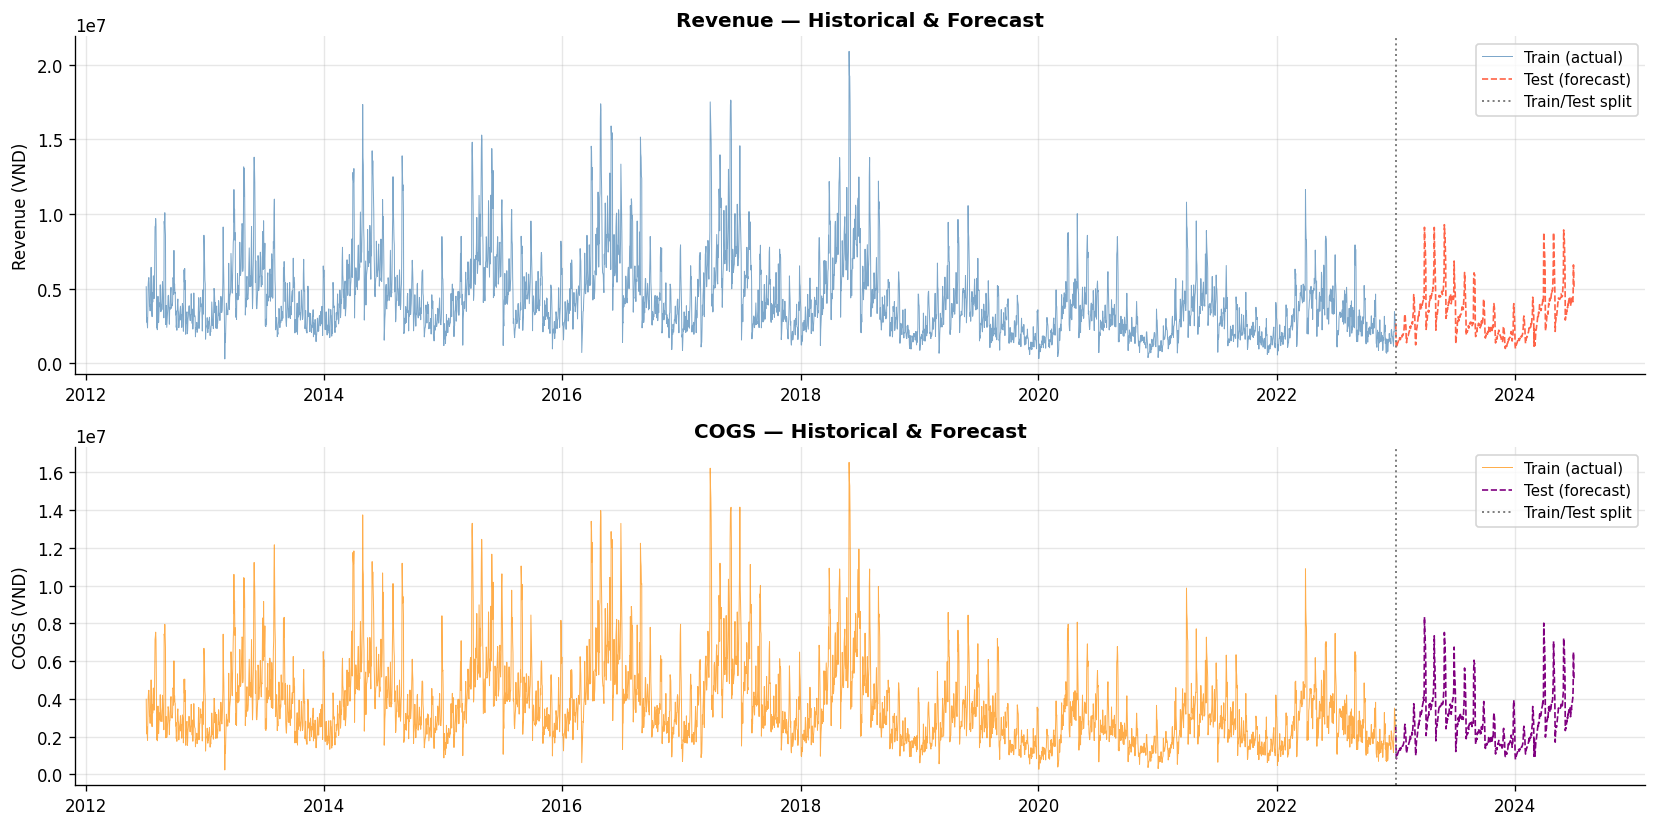

📊 Chart saved: plot_04_forecast_vs_actual.png


In [12]:
# ── Trực quan hoá dự báo vs lịch sử ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# -- Revenue --
axes[0].plot(train['Date'], train['Revenue'], lw=0.6, color='steelblue',  label='Train (actual)', alpha=0.7)
axes[0].plot(test['Date'],  test['Revenue'],  lw=1.0, color='tomato',     label='Test (forecast)', ls='--')
axes[0].axvline(pd.Timestamp('2023-01-01'), lw=1.2, ls=':', color='gray', label='Train/Test split')
axes[0].set_title('Revenue — Historical & Forecast', fontweight='bold')
axes[0].set_ylabel('Revenue (VND)')
axes[0].legend(fontsize=9)

# -- COGS --
axes[1].plot(train['Date'], train['COGS'], lw=0.6, color='darkorange', label='Train (actual)', alpha=0.7)
axes[1].plot(test['Date'],  test['COGS'],  lw=1.0, color='purple',     label='Test (forecast)', ls='--')
axes[1].axvline(pd.Timestamp('2023-01-01'), lw=1.2, ls=':', color='gray', label='Train/Test split')
axes[1].set_title('COGS — Historical & Forecast', fontweight='bold')
axes[1].set_ylabel('COGS (VND)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_04_forecast_vs_actual.png', bbox_inches='tight')
plt.show()
print('📊 Chart saved: plot_04_forecast_vs_actual.png')

---
## 6 — Evaluate — Validation MAPE (Sanity-check)

Áp dụng **đúng chiến lược trên** cho giai đoạn 2021–2022 (phần cuối tập train mà ta biết nhãn thật) để đo **MAPE** — chỉ số đánh giá phổ biến trong dự báo chuỗi thời gian.

$$
\text{MAPE} = \frac{1}{n} \sum_{t=1}^{n} \left| \frac{y_t - \hat{y}_t}{y_t} \right| \times 100
$$

> **Lưu ý:** MAPE có thể bị ảnh hưởng bởi các ngày có giá trị thực rất nhỏ (phân mẫu số nhỏ). Ở đây ta cũng tính thêm **MAE** và **RMSE** cho toàn diện.

In [13]:
# ── Hàm tính các chỉ số lỗi ─────────────────────────────────────────────────
def mape(actual: pd.Series, pred: pd.Series) -> float:
    """Mean Absolute Percentage Error (%)."""
    # Loại trừ các ngày có actual = 0 để tránh chia cho 0
    mask = actual != 0
    return (np.abs(actual[mask] - pred[mask]) / np.abs(actual[mask])).mean() * 100

def mae(actual: pd.Series, pred: pd.Series) -> float:
    """Mean Absolute Error."""
    return np.abs(actual - pred).mean()

def rmse(actual: pd.Series, pred: pd.Series) -> float:
    """Root Mean Squared Error."""
    return np.sqrt(((actual - pred) ** 2).mean())

def r2(actual: pd.Series, pred: pd.Series) -> float:
    """R² — Coefficient of Determination."""
    ss_res = ((actual - pred) ** 2).sum()
    ss_tot = ((actual - actual.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

print('✅ Metric functions defined.')

✅ Metric functions defined.


In [14]:
# ── Cắt tập validation: 2021 – 2022 ─────────────────────────────────────────
VAL_YEARS = [2021, 2022]
val = train[train['year'].isin(VAL_YEARS)].copy()

# xóa các cột norm cũ (từ Section 4) trước khi merge với seasonal để tránh pandas đổi tên thành rev_norm_x / rev_norm_y
val = val.drop(columns=['rev_norm', 'cogs_norm'], errors='ignore')

# Gán seasonal factor
val = val.merge(seasonal, on=['month', 'day'], how='left')
val['rev_norm']  = val['rev_norm'].fillna(1.0)
val['cogs_norm'] = val['cogs_norm'].fillna(1.0)

# years_ahead âm (2021→ -1, 2022→ 0)
val['years_ahead'] = val['year'] - BASE_YEAR

# Dự báo
val['Revenue_pred'] = base_rev  * growth_rev**val['years_ahead']  * val['rev_norm']
val['COGS_pred']    = base_cogs * growth_cogs**val['years_ahead'] * val['cogs_norm']

# ── Báo cáo chỉ số ────────────────────────────────────────────────────────────
print('=' * 55)
print('          VALIDATION METRICS (2021 – 2022)')
print('=' * 55)
for target, pred_col in [('Revenue', 'Revenue_pred'), ('COGS', 'COGS_pred')]:
    _mape = mape(val[target], val[pred_col])
    _mae  = mae(val[target],  val[pred_col])
    _rmse = rmse(val[target], val[pred_col])
    _r2   = r2(val[target],   val[pred_col])
    print(f'  {target:<8} → MAPE: {_mape:6.2f}%  │  MAE: {_mae:,.0f}  │  RMSE: {_rmse:,.0f}  │  R²: {_r2:.4f}')
print('=' * 55)

          VALIDATION METRICS (2021 – 2022)
  Revenue  → MAPE:  25.53%  │  MAE: 612,312  │  RMSE: 798,824  │  R²: 0.7704
  COGS     → MAPE:  23.49%  │  MAE: 506,418  │  RMSE: 665,229  │  R²: 0.7896


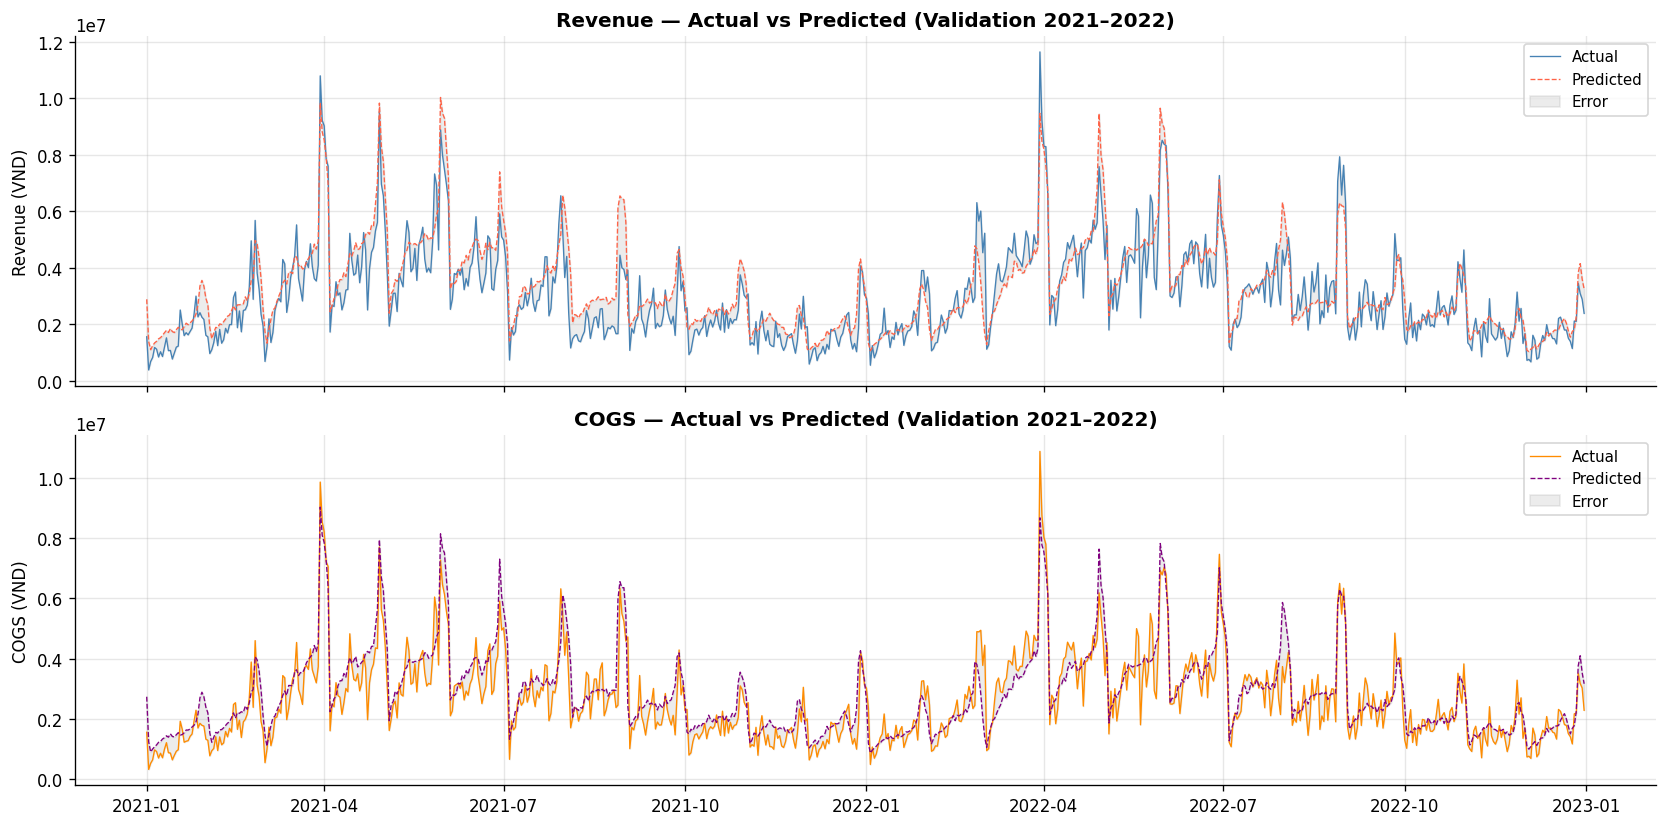

📊 Chart saved: plot_05_validation.png


In [15]:
# ── Trực quan hoá Actual vs Predicted trên tập Validation ────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Revenue
axes[0].plot(val['Date'], val['Revenue'],      lw=0.8, color='steelblue',  label='Actual')
axes[0].plot(val['Date'], val['Revenue_pred'], lw=0.8, color='tomato',     label='Predicted', ls='--')
axes[0].fill_between(
    val['Date'],
    val['Revenue'],
    val['Revenue_pred'],
    alpha=0.15, color='gray', label='Error'
)
axes[0].set_title('Revenue — Actual vs Predicted (Validation 2021–2022)', fontweight='bold')
axes[0].set_ylabel('Revenue (VND)')
axes[0].legend(fontsize=9)

# COGS
axes[1].plot(val['Date'], val['COGS'],      lw=0.8, color='darkorange', label='Actual')
axes[1].plot(val['Date'], val['COGS_pred'], lw=0.8, color='purple',     label='Predicted', ls='--')
axes[1].fill_between(
    val['Date'],
    val['COGS'],
    val['COGS_pred'],
    alpha=0.15, color='gray', label='Error'
)
axes[1].set_title('COGS — Actual vs Predicted (Validation 2021–2022)', fontweight='bold')
axes[1].set_ylabel('COGS (VND)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_05_validation.png', bbox_inches='tight')
plt.show()
print('📊 Chart saved: plot_05_validation.png')

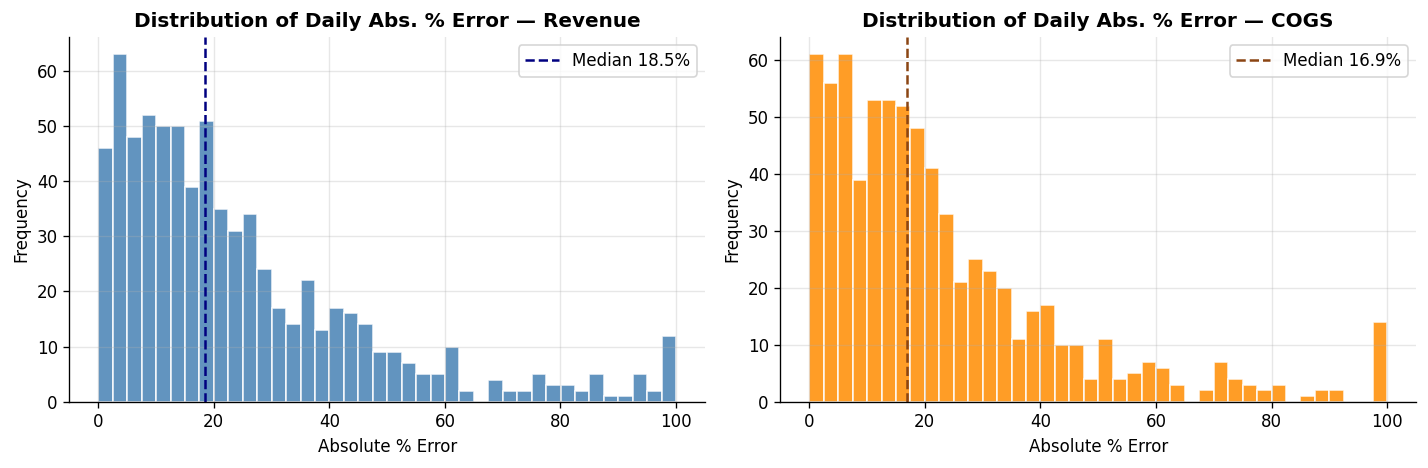

📊 Chart saved: plot_06_error_distribution.png


In [16]:
# ── Phân phối lỗi tương đối (MAPE per day) ───────────────────────────────────
val['pct_err_rev']  = (val['Revenue']      - val['Revenue_pred']).abs() / val['Revenue'].abs() * 100
val['pct_err_cogs'] = (val['COGS']         - val['COGS_pred']).abs()    / val['COGS'].abs()    * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(val['pct_err_rev'].clip(upper=100),  bins=40, color='steelblue',  edgecolor='white', alpha=0.85)
axes[0].axvline(val['pct_err_rev'].median(), ls='--', color='navy', lw=1.5, label=f'Median {val["pct_err_rev"].median():.1f}%')
axes[0].set_title('Distribution of Daily Abs. % Error — Revenue', fontweight='bold')
axes[0].set_xlabel('Absolute % Error'); axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(val['pct_err_cogs'].clip(upper=100), bins=40, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(val['pct_err_cogs'].median(), ls='--', color='saddlebrown', lw=1.5, label=f'Median {val["pct_err_cogs"].median():.1f}%')
axes[1].set_title('Distribution of Daily Abs. % Error — COGS', fontweight='bold')
axes[1].set_xlabel('Absolute % Error'); axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_06_error_distribution.png', bbox_inches='tight')
plt.show()
print('📊 Chart saved: plot_06_error_distribution.png')

---
## 7 — Export Submission

### Yêu cầu định dạng Kaggle

```csv
Date,Revenue,COGS
2023-01-01,26607.2,2585.15
2023-01-02,1007.89,163.0
...
```

Các kiểm tra trước khi xuất:
1. **Số dòng** phải khớp `sample_submission.csv`
2. **Thứ tự** theo `Date` tăng dần
3. **Tên cột** chính xác: `Date`, `Revenue`, `COGS`
4. **Không có index** rác
5. **Không có NaN** trong bất kỳ ô nào

In [17]:
# ── Xây dựng submission DataFrame ────────────────────────────────────────────
submission = (
    test[['Date', 'Revenue', 'COGS']]
    .sort_values('Date')           # đảm bảo thứ tự tăng dần theo ngày
    .reset_index(drop=True)        # xóa index cũ
)

# Format cột Date thành string YYYY-MM-DD
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')

# ── Validation trước khi xuất ─────────────────────────────────────────────────
print('=== PRE-EXPORT VALIDATION ===')
print(f'  Số dòng        : {len(submission)}')
print(f'  Cột            : {list(submission.columns)}')
print(f'  Ngày đầu       : {submission["Date"].iloc[0]}')
print(f'  Ngày cuối      : {submission["Date"].iloc[-1]}')
print(f'  Missing values : {submission.isnull().sum().to_dict()}')
print(f'  Revenue < 0    : {(submission["Revenue"] < 0).sum()}')
print(f'  COGS < 0       : {(submission["COGS"] < 0).sum()}')
print()

# So sánh với sample_submission nếu tồn tại
try:
    sample = pd.read_csv(SAMPLE_SUB)
    print(f'  Sample rows    : {len(sample)}')
    assert len(submission) == len(sample), '❌ Số dòng KHÔNG khớp sample_submission!'
    print('  ✅ Số dòng khớp sample_submission.')
except FileNotFoundError:
    print(f'  ⚠️  Không tìm thấy {SAMPLE_SUB}, bỏ qua kiểm tra số dòng.')

print()
print('Preview submission (10 dòng đầu):')
print(submission.head(10).to_string(index=False))

=== PRE-EXPORT VALIDATION ===
  Số dòng        : 548
  Cột            : ['Date', 'Revenue', 'COGS']
  Ngày đầu       : 2023-01-01
  Ngày cuối      : 2024-07-01
  Missing values : {'Date': 0, 'Revenue': 0, 'COGS': 0}
  Revenue < 0    : 0
  COGS < 0       : 0

  Sample rows    : 548
  ✅ Số dòng khớp sample_submission.

Preview submission (10 dòng đầu):
      Date    Revenue       COGS
2023-01-01 2665507.20 2518885.15
2023-01-02 1280007.89 1136463.00
2023-01-03 1015899.51  822721.12
2023-01-04 1142997.27  914554.18
2023-01-05 1236312.34  984390.24
2023-01-06 1289094.55 1040418.44
2023-01-07 1370539.45 1119430.49
2023-01-08 1409121.71 1142951.32
2023-01-09 1483990.79 1221315.20
2023-01-10 1570643.46 1258681.76


In [18]:
# ── Xuất file CSV ─────────────────────────────────────────────────────────────
submission.to_csv(
    OUT_FILE,
    index=False,          # ← quan trọng: không xuất index ra file
    encoding='utf-8',
)

print(f'✅ Đã lưu {len(submission)} dòng vào "{OUT_FILE}"')
print()

# ── Kiểm tra bằng cách đọc lại ───────────────────────────────────────────────
verify = pd.read_csv(OUT_FILE)
print('Kiểm tra file vừa xuất:')
print(f'  Shape          : {verify.shape}')
print(f'  Cột            : {list(verify.columns)}')
print(f'  Dtypes         : {verify.dtypes.to_dict()}')
print(f'  Missing values : {verify.isnull().sum().to_dict()}')
print()
print(verify.tail(5).to_string(index=False))
print()
print('🚀 submission.csv sẵn sàng nộp lên Kaggle!')

✅ Đã lưu 548 dòng vào "submission.csv"

Kiểm tra file vừa xuất:
  Shape          : (548, 3)
  Cột            : ['Date', 'Revenue', 'COGS']
  Dtypes         : {'Date': dtype('O'), 'Revenue': dtype('float64'), 'COGS': dtype('float64')}
  Missing values : {'Date': 0, 'Revenue': 0, 'COGS': 0}

      Date    Revenue       COGS
2024-06-27 4111585.95 4048492.76
2024-06-28 4591751.39 4504603.05
2024-06-29 6582807.93 6478608.03
2024-06-30 5484749.90 5386065.13
2024-07-01 5057610.99 4989753.02

🚀 submission.csv sẵn sàng nộp lên Kaggle!
